In [1]:
# If running in Google Colab, mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

Mounted at /content/drive


In [2]:
# =============================
# Imports
# =============================

import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input as mb_preprocess
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input


In [3]:
# ====== Source folders in your Google Drive ======
DATASET_ROOT = "/content/drive/MyDrive/BrainTumorProject/archive"

train_src = DATASET_ROOT + "/Training"
test_src  = DATASET_ROOT + "/Testing"

# ====== Target folders in Colab ======
binary_base = "/content/data_binary"
multi_base  = "/content/data_multiclass"

# Remove old folders if exist (to avoid duplication)
shutil.rmtree(binary_base, ignore_errors=True)
shutil.rmtree(multi_base, ignore_errors=True)

# Create main folders
os.makedirs(binary_base + "/train/tumor", exist_ok=True)
os.makedirs(binary_base + "/train/notumor", exist_ok=True)
os.makedirs(binary_base + "/val/tumor", exist_ok=True)
os.makedirs(binary_base + "/val/notumor", exist_ok=True)
os.makedirs(binary_base + "/test/tumor", exist_ok=True)
os.makedirs(binary_base + "/test/notumor", exist_ok=True)

os.makedirs(multi_base + "/train/glioma", exist_ok=True)
os.makedirs(multi_base + "/train/meningioma", exist_ok=True)
os.makedirs(multi_base + "/train/pituitary", exist_ok=True)

os.makedirs(multi_base + "/val/glioma", exist_ok=True)
os.makedirs(multi_base + "/val/meningioma", exist_ok=True)
os.makedirs(multi_base + "/val/pituitary", exist_ok=True)

os.makedirs(multi_base + "/test/glioma", exist_ok=True)
os.makedirs(multi_base + "/test/meningioma", exist_ok=True)
os.makedirs(multi_base + "/test/pituitary", exist_ok=True)
# ================================
#   PROCESS TRAINING DATA
# ================================

classes = ["glioma", "meningioma", "pituitary", "notumor"]

for cls in classes:
    src_folder = f"{train_src}/{cls}"
    images = os.listdir(src_folder)

    # Split 80% train / 20% val
    train_files, val_files = train_test_split(images, test_size=0.2, random_state=42)

    for f in train_files:
        # MULTICLASS — only if not 'notumor'
        if cls != "notumor":
            shutil.copy(f"{src_folder}/{f}", f"{multi_base}/train/{cls}/{f}")

        # BINARY — tumor = 1, notumor = 0
        target = "tumor" if cls != "notumor" else "notumor"
        shutil.copy(f"{src_folder}/{f}", f"{binary_base}/train/{target}/{f}")

    for f in val_files:
        if cls != "notumor":
            shutil.copy(f"{src_folder}/{f}", f"{multi_base}/val/{cls}/{f}")

        target = "tumor" if cls != "notumor" else "notumor"
        shutil.copy(f"{src_folder}/{f}", f"{binary_base}/val/{target}/{f}")
# ================================
#   PROCESS TESTING DATA
# ================================

for cls in classes:
    src_folder = f"{test_src}/{cls}"
    images = os.listdir(src_folder)

    for f in images:
        if cls != "notumor":
            shutil.copy(f"{src_folder}/{f}", f"{multi_base}/test/{cls}/{f}")

        target = "tumor" if cls != "notumor" else "notumor"
        shutil.copy(f"{src_folder}/{f}", f"{binary_base}/test/{target}/{f}")
print("Dataset prepared successfully!")

Dataset prepared successfully!


In [4]:
# paths
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)
binary_model_path = os.path.join(MODEL_DIR, "stage1_binary_mobilenet.h5")

binary_train_dir = "/content/data_binary/train"
binary_val_dir   = "/content/data_binary/val"
binary_test_dir  = "/content/data_binary/test"

# Generator

train_datagen_bin = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=8,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.08
)

val_datagen_bin = ImageDataGenerator(rescale=1.0/255.0)
test_datagen_bin = ImageDataGenerator(rescale=1.0/255.0)

train_gen_bin = train_datagen_bin.flow_from_directory(
    binary_train_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=True
)

val_gen_bin = val_datagen_bin.flow_from_directory(
    binary_val_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False
)

test_gen_bin = test_datagen_bin.flow_from_directory(
    binary_test_dir, target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False
)

# Build model function
def build_binary_model():
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(224,224,3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Callbacks
checkpoint_cb = ModelCheckpoint(binary_model_path, save_best_only=True, monitor="val_accuracy", mode="max")
early_cb = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

print("Training Stage-1 MobileNetV2 model...")

stage1_model = build_binary_model()

history = stage1_model.fit(
    train_gen_bin,
    validation_data=val_gen_bin,
    epochs=5,
    callbacks=[checkpoint_cb, early_cb]
)

stage1_model.save(binary_model_path)

print("Stage-1 training complete and model saved locally.")

# quick eval on test set
test_loss, test_acc = stage1_model.evaluate(test_gen_bin)
print(f"Stage-1 Test accuracy: {test_acc:.4f}")
stage1_model.summary()


Found 4568 images belonging to 2 classes.
Found 1144 images belonging to 2 classes.
Found 1312 images belonging to 2 classes.
Training Stage-1 MobileNetV2 model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7792 - loss: 0.4246

143/143 ━━━━━━━━━━━━━━━━━━━━ 98s 548ms/step - accuracy: 0.7799 - loss: 0.4236 - val_accuracy: 0.9580 - val_loss: 0.1217
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9531 - loss: 0.1367

143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 401ms/step - accuracy: 0.9531 - loss: 0.1367 - val_accuracy: 0.9773 - val_loss: 0.0856
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9666 - loss: 0.1084

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [5]:
# ----------------------------
# SECTION 6 — Stage-2 (Multiclass) generators + auto-load/train EfficientNetB0
# ----------------------------
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)
stage2_model_path = os.path.join(MODEL_DIR, "stage2_multiclass_efficientnet.h5")

# directories created earlier by Section 4
multi_train_dir = "/content/data_multiclass/train"
multi_val_dir   = "/content/data_multiclass/val"
multi_test_dir  = "/content/data_multiclass/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# -- data generators using EfficientNet preprocessing --
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1
)
val_datagen_eff = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_eff = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_eff = train_datagen_eff.flow_from_directory(
    multi_train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen_eff = val_datagen_eff.flow_from_directory(
    multi_val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen_eff = test_datagen_eff.flow_from_directory(
    multi_test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# -- build function --
def build_stage2_model():
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
    base.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    out = tf.keras.layers.Dense(3, activation='softmax')(x)
    model = tf.keras.Model(inputs=base.input, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# callbacks
checkpoint_eff = ModelCheckpoint(stage2_model_path, save_best_only=True, monitor="val_accuracy", mode="max")
earlystop_eff = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Training Stage-2 EfficientNetB0 model...")

stage2_model = build_stage2_model()

history = stage2_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=8,
    callbacks=[checkpoint_eff, earlystop_eff]
)

stage2_model.save(stage2_model_path)

print("Stage-2 training complete and model saved locally.")

# Evaluate on test set
test_loss, test_acc = stage2_model.evaluate(test_gen_eff)
print(f"Stage-2 Test accuracy: {test_acc:.4f}")
stage2_model.summary()


Found 3292 images belonging to 3 classes.
Found 825 images belonging to 3 classes.
Found 907 images belonging to 3 classes.
Training Stage-2 EfficientNetB0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.5165 - loss: 0.9851

103/103 ━━━━━━━━━━━━━━━━━━━━ 101s 749ms/step - accuracy: 0.5176 - loss: 0.9834 - val_accuracy: 0.7442 - val_loss: 0.6018
Epoch 2/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7926 - loss: 0.5439

103/103 ━━━━━━━━━━━━━━━━━━━━ 41s 400ms/step - accuracy: 0.7927 - loss: 0.5436 - val_accuracy: 0.7685 - val_loss: 0.5639
Epoch 3/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8287 - loss: 0.4484

103/103 ━━━━━━━━━━━━━━━━━━━━ 41s 397ms/step - accuracy: 0.8287 - loss: 0.4484 - val_accuracy: 0.7770 - val_loss: 0.5534
Epoch 4/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8574 - loss: 0.3926

103/103 ━━━━━━━━━━━━━━━━━━━━ 41s 403ms/step - accuracy: 0.8573 - loss: 0.3926 - val_accuracy: 0.7939 - val_loss: 0.5157
Epoch 5/8
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8600 - loss: 0.3850

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,035,694 (19.21 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 657,416 (2.51 MB)

#Results

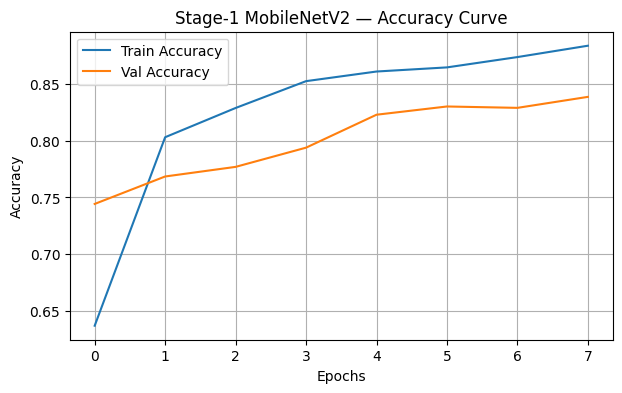

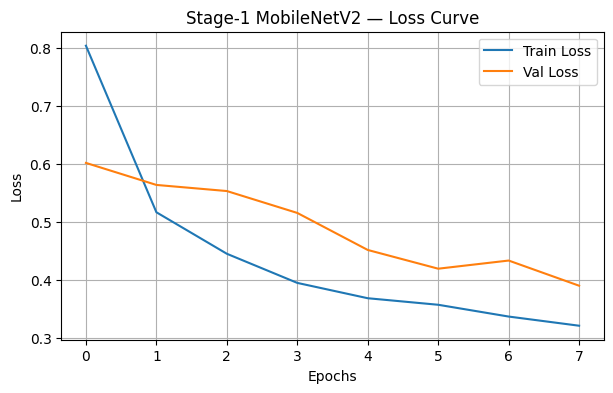

In [9]:
# --- Stage-1: Accuracy Curve ---
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Stage-1 MobileNetV2 — Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# --- Stage-1: Loss Curve ---
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Stage-1 MobileNetV2 — Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step


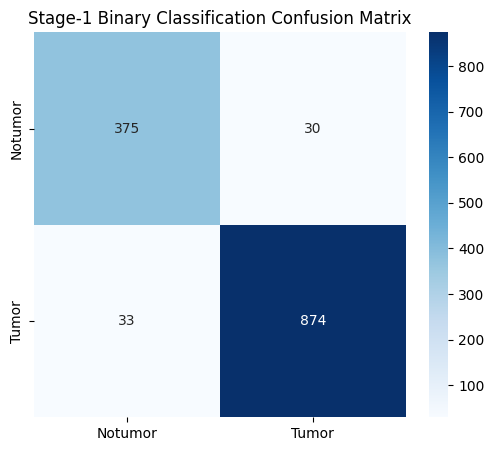

Stage-1 Binary Classification Report:
              precision    recall  f1-score   support

     Notumor       0.92      0.93      0.92       405
       Tumor       0.97      0.96      0.97       907

    accuracy                           0.95      1312
   macro avg       0.94      0.94      0.94      1312
weighted avg       0.95      0.95      0.95      1312



In [10]:
# Predictions
y_true_bin = test_gen_bin.classes
y_pred_bin = (stage1_model.predict(test_gen_bin) > 0.5).astype(int)

cm_bin = confusion_matrix(y_true_bin, y_pred_bin)

plt.figure(figsize=(6,5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Notumor','Tumor'],
            yticklabels=['Notumor','Tumor'])
plt.title("Stage-1 Binary Classification Confusion Matrix")
plt.show()

print("Stage-1 Binary Classification Report:")
print(classification_report(y_true_bin, y_pred_bin, target_names=['Notumor','Tumor']))


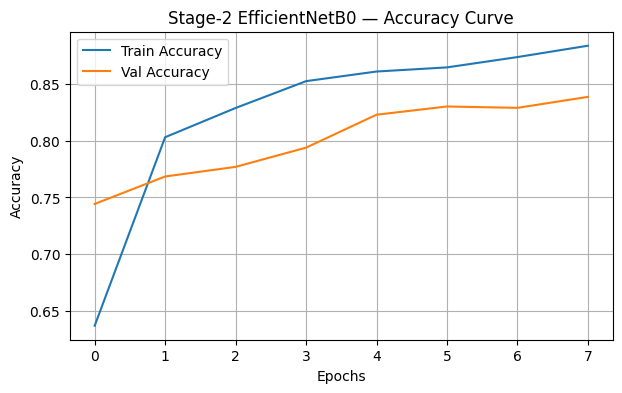

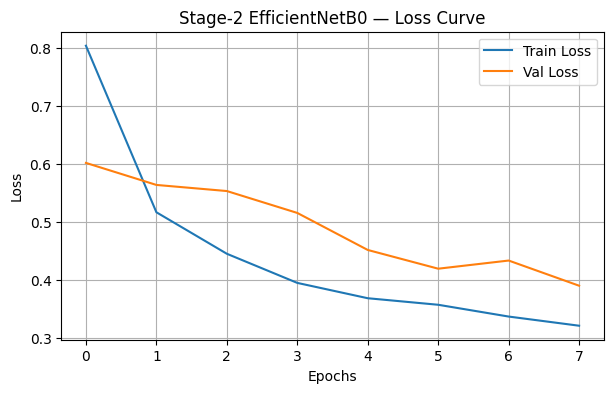

In [11]:

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Stage-2 EfficientNetB0 — Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.legend(); plt.grid()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Stage-2 EfficientNetB0 — Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.legend(); plt.grid()
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 327ms/step


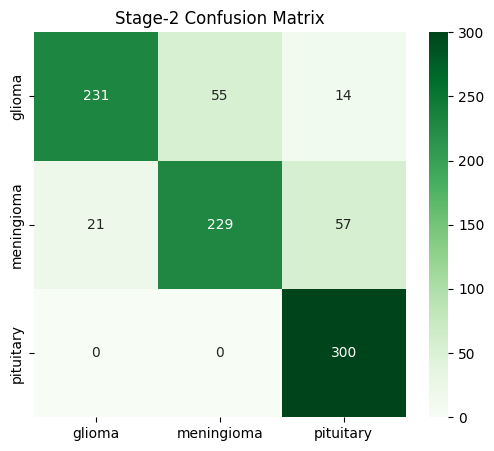


Stage-2 Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.77      0.84       300
  meningioma       0.81      0.75      0.77       307
   pituitary       0.81      1.00      0.89       300

    accuracy                           0.84       907
   macro avg       0.84      0.84      0.84       907
weighted avg       0.84      0.84      0.83       907



In [12]:
# Corrected Stage-2 Evaluation Block

# true labels
y_true_multi = test_gen_eff.classes

# model predictions
y_prob_multi = stage2_model.predict(test_gen_eff)
y_pred_multi = np.argmax(y_prob_multi, axis=1)

# confusion matrix
cm_multi = confusion_matrix(y_true_multi, y_pred_multi)

plt.figure(figsize=(6,5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(test_gen_eff.class_indices.keys()),
            yticklabels=list(test_gen_eff.class_indices.keys()))
plt.title("Stage-2 Confusion Matrix")
plt.show()

# classification report
print("\nStage-2 Classification Report:")
print(classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=list(test_gen_eff.class_indices.keys())
))


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


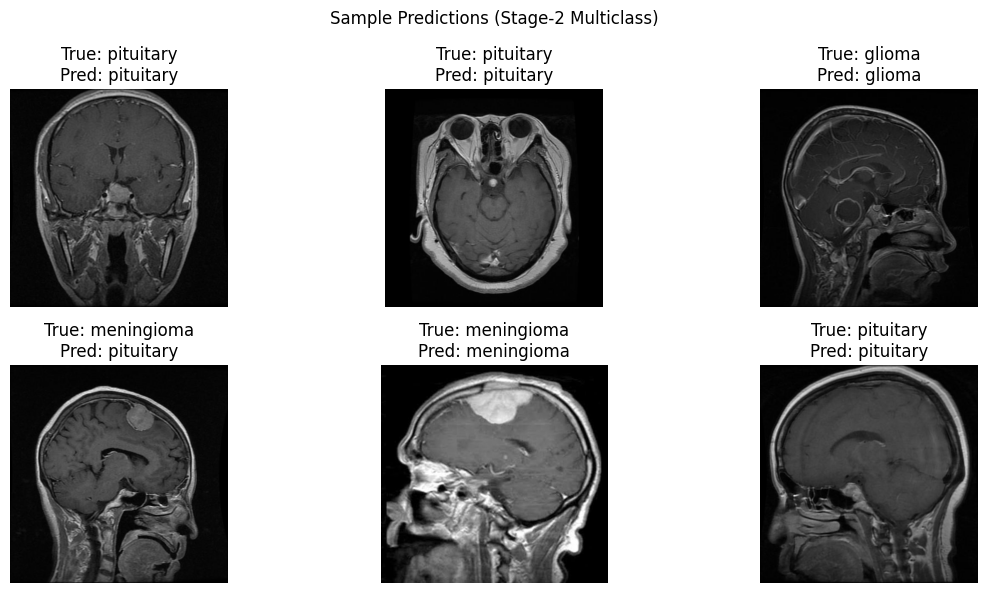

In [13]:

def show_random_predictions(n=6):
    plt.figure(figsize=(12,6))
    files = test_gen_eff.filenames   # FIXED
    indices = random.sample(range(len(files)), n)

    for i, idx in enumerate(indices):
        img_path = os.path.join(multi_test_dir, files[idx])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (224,224))

        # Prediction
        arr = preprocess_input(np.expand_dims(resized,0))
        pred = stage2_model.predict(arr)[0]
        pred_label = list(test_gen_eff.class_indices.keys())[np.argmax(pred)]

        true_label = files[idx].split('/')[0]

        plt.subplot(2, n//2, i+1)
        plt.imshow(img_rgb)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')

    plt.suptitle("Sample Predictions (Stage-2 Multiclass)")
    plt.tight_layout()
    plt.show()

show_random_predictions()


Grad-CAM Visualization

In [14]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_score = predictions[:, pred_index]

    grads = tape.gradient(pred_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [15]:
def generate_gradcam(image_path, model, last_conv_layer="top_conv"):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Preprocess for EfficientNet
    input_arr = preprocess_input(np.expand_dims(img_resized, axis=0))

    # Create heatmap
    heatmap = make_gradcam_heatmap(input_arr, model, last_conv_layer)

    # Resize heatmap to original image size
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))

    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img_rgb, 0.65, heatmap_color, 0.35, 0)

    # Show results
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.show()


Image: /content/data_multiclass/test/meningioma/Te-me_0278.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_158']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


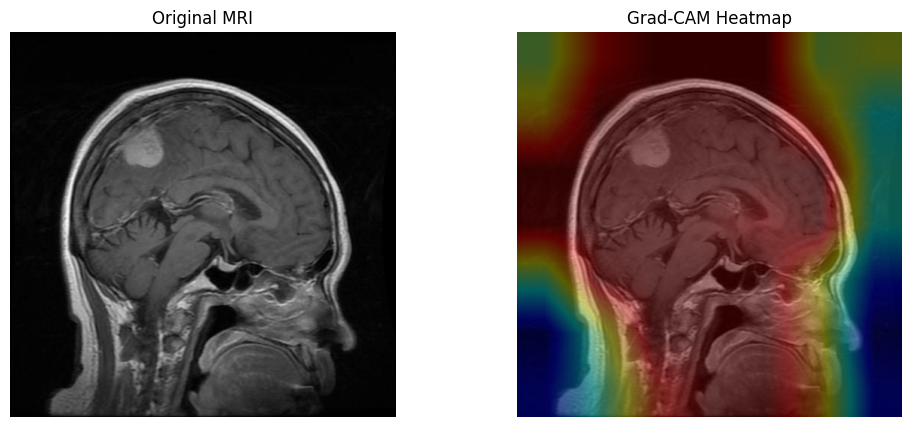

In [16]:
def demo_gradcam_random():
    # Choose a random MRI from the test dataset
    files = test_gen_eff.filenames
    rand_idx = random.randint(0, len(files)-1)

    img_path = os.path.join(multi_test_dir, files[rand_idx])
    print("Image:", img_path)

    generate_gradcam(img_path, stage2_model)

demo_gradcam_random()


In [17]:
# ----------------------------
# Grad-CAM + Prediction Visualization
# ----------------------------

class_names = list(test_gen_eff.class_indices.keys())

def visualize_prediction(image_path, model_stage1=stage1_model, model_stage2=stage2_model, last_conv="top_conv"):
    """
    Runs the full pipeline on a single image and displays:
     - Original image
     - Grad-CAM overlay (Stage-2)
     - Probability bar chart for tumor classes
    """

    img = cv2.imread(image_path)
    if img is None:
        print("Error: Cannot read image:", image_path)
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (224,224))

    # Stage-1 Prediction (Binary)
    bin_input = np.expand_dims(resized / 255.0, axis=0)
    s1_prob = float(model_stage1.predict(bin_input)[0][0])
    s1_label = "Tumor" if s1_prob >= 0.5 else "No Tumor"

    # Stage-2 Prediction (Multiclass)
    eff_input = preprocess_input(np.expand_dims(resized, axis=0))
    s2_probs = model_stage2.predict(eff_input)[0]
    s2_idx = int(np.argmax(s2_probs))
    s2_label = class_names[s2_idx]
    s2_conf = float(s2_probs[s2_idx])

    # Grad-CAM
    heatmap = make_gradcam_heatmap(eff_input, model_stage2, last_conv)
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_rgb, 0.65, heatmap_color, 0.35, 0)

    # Visualization
    fig = plt.figure(figsize=(14,5))

    ax1 = fig.add_subplot(1,3,1)
    ax1.imshow(img_rgb)
    ax1.axis('off')
    ax1.set_title("Original MRI")

    ax2 = fig.add_subplot(1,3,2)
    ax2.imshow(overlay)
    ax2.axis('off')
    ax2.set_title(f"Grad-CAM ({s2_label})")

    ax3 = fig.add_subplot(1,3,3)
    bars = ax3.barh(class_names[::-1], list(s2_probs[::-1]))
    ax3.set_xlim(0,1)
    ax3.invert_yaxis()
    ax3.set_title("Stage-2 Class Probabilities")

    for i, b in enumerate(bars):
        ax3.text(b.get_width()+0.01, b.get_y()+b.get_height()/2,
                 f"{b.get_width():.2f}", va='center')

    plt.suptitle(f"Stage-1: {s1_label} (p={s1_prob:.2f}) | Stage-2: {s2_label} (p={s2_conf:.2f})")
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


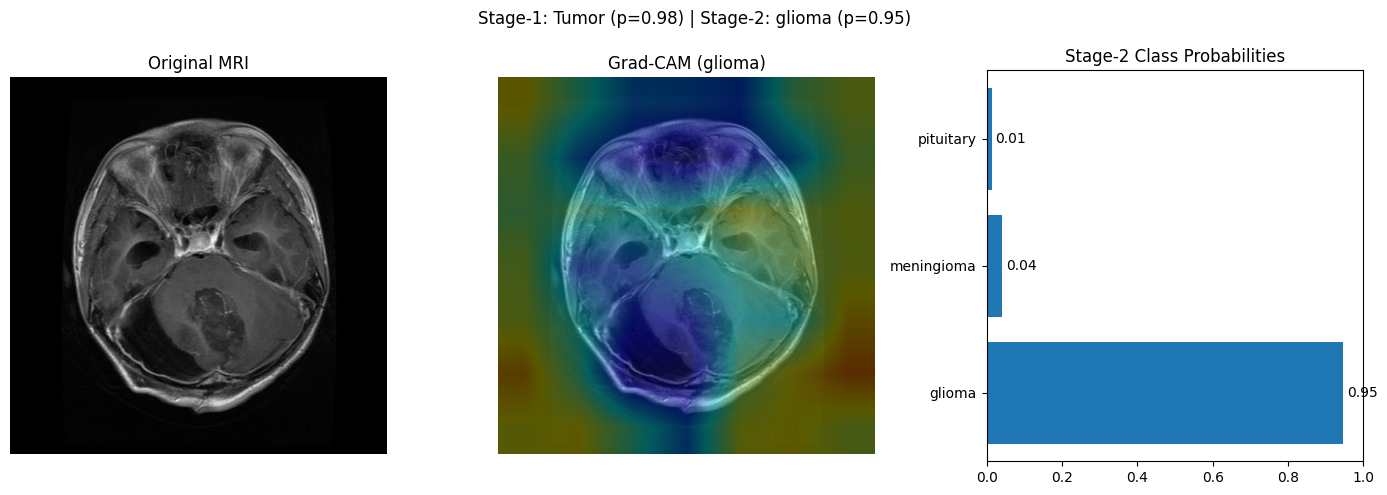

In [18]:
# Example visualization (select one test image manually)
files = test_gen_eff.filenames
example_path = os.path.join(multi_test_dir, files[0])
visualize_prediction(example_path)

## Conclusion

This work presents a dual-stage deep learning pipeline for automated brain tumor detection and classification using transfer learning.

Stage-1 (MobileNetV2) performs binary tumor detection, while Stage-2 (EfficientNetB0) classifies tumor types. The architecture demonstrates strong performance and interpretability through Grad-CAM visualization.

Future improvements may include:
- Fine-tuning deeper layers
- Cross-validation for robustness
- Hyperparameter optimization
- Deployment as a lightweight clinical decision-support prototype